In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
%matplotlib inline
import matplotlib.pyplot as plt
import sys # sys.path

CO2 Time Series (ppm):
[278.         280.78       283.5878     286.423678   289.28791478
 292.18079393 295.10260187 298.05362789 301.03416416 304.04450581
 307.08495086 310.15580037 313.25735838 316.38993196 319.55383128
 322.74936959 325.97686329 329.23663192 332.52899824 335.85428822
 339.21283111 342.60495942 346.03100901 349.4913191  352.98623229
 356.51609461 360.08125556 363.68206812 367.3188888  370.99207769
 374.70199846 378.44901845 382.23350863 386.05584372 389.91640216
 393.81556618 397.75372184 401.73125906 405.74857165 409.80605736
 413.90411794 418.04315912 422.22359071 426.44582662 430.71028488
 435.01738773 439.36756161 443.76123722 448.1988496  452.68083809
 457.20764647 461.77972294 466.39752017 471.06149537 475.77211032
 480.52983143 485.33512974 490.18848104 495.09036585 500.04126951
 505.0416822  510.09209902 515.19302001 520.34495021 525.54839972
 530.80388371 536.11192255 541.47304178 546.88777219 552.35664991
 557.88021641 563.45901858 569.09360876 574.78454485 

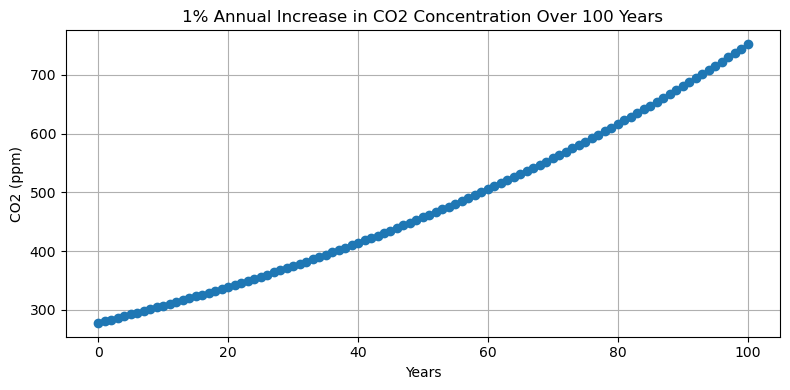

In [2]:
def generate_co2_forcing(initial_co2=278, annual_increase=0.01, years=100):
    """
    Generates a CO2 time series with an annual percentage increase.
    
    Parameters:
        initial_co2 (float): Starting CO2 concentration (ppm). Default is 278 ppm.
        annual_increase (float): Annual percentage increase as a decimal (1% = 0.01).
        years (int): Number of years for the simulation.
    
    Returns:
        np.ndarray: Array containing CO2 concentration for each year (0 to years).
    """
    # Create an array of time points (from 0 to years)
    time = np.arange(years + 1)
    
    # Calculate the time series using the exponential growth formula
    co2_series = initial_co2 * (1 + annual_increase) ** time
    
    return co2_series

# Example usage:
if __name__ == "__main__":
    # Generate the CO2 forcing time series
    co2_series = generate_co2_forcing()
    
    # Print the series
    print("CO2 Time Series (ppm):")
    print(co2_series)
    
    # Plot the series
    plt.figure(figsize=(8, 4))
    plt.plot(co2_series, marker='o', linestyle='-')
    plt.xlabel('Years')
    plt.ylabel('CO2 (ppm)')
    plt.title('1% Annual Increase in CO2 Concentration Over 100 Years')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
def co2_ratio(co2_series, c0=278.0):
    # co2_series, is the estimated co2 concentration for a specific year
    # c0, is the estimated preindustrial level for co2 concentration
    result = co2_series / c0 
    return result

ratio = co2_ratio(co2_series)

#############################################################################################
# Create a dataframe for parameters in our ode function...
#############################################################################################
df_table = pd.read_csv('Documents/Masters Thesis CSV/Geoffroy_parameters_EBM1_CMIP6.csv')
Model=df_table['Model']
ECS=df_table['ECS']
Gamma=df_table['gamma']
F2=df_table['F_2x']
Lambda=df_table['lambda']
cs=df_table['C']
cd=df_table['C0']

# Create Dataframe
df_constants=pd.DataFrame({'Model':Model,'F2':F2,'Gamma':Gamma, 'Lambda':Lambda, 'ECS':ECS, 'CS':cs, 'CD':cd})

# Constants
F2 = np.array(df_constants.iloc[:,1])
gamma = np.array(df_constants.iloc[:,2])
lamb = np.array(df_constants.iloc[:,3])
ECS = np.array(df_constants.iloc[:,4])
cs = np.array(df_constants.iloc[:,5])
cd = np.array(df_constants.iloc[:,6])

# -----------------------------------------------------------------------------
# extract arrays and model names
# -----------------------------------------------------------------------------
model_names = df_table['Model'].values  # Array of model names
F2 = df_table['F_2x'].values
gamma = df_table['gamma'].values
lamb = df_table['lambda'].values
cs = df_table['C'].values
cd = df_table['C0'].values

# Coupled ODE function for Energy Balanced Model(EBM)
def secondorder(T,t,gamma,lamb,f,cs,cd,e=1):
    dT0dt = (f-T[0]*(lamb+gamma)+ gamma*T[1]-(e-1))/cs    
    dT1dt = (gamma * (T[0] - T[1] ))/cd # T[0]>>>atmosphere, T[1]>>>deep
    return [dT0dt, dT1dt]

def run(time,forcing,gamma,lamb,cs,cd):
    T_start=np.array([0,0])
    Ts=np.zeros(shape=[len(t),2])
    Ts[0,:] = T_start
    for i in range(len(time)-1):
        ts=[time[i], time[i+1]]
        f=forcing[i] # index:year, rcp scenario
        T=odeint(secondorder,T_start,ts,args=(gamma,lamb,f,cs,cd))
        T_start = T[1,:]
        Ts[i+1,:]=T_start
    return Ts

def log_linear(ratio, force=F2[0], base=2):
    result = force*np.log(ratio)/np.log(base)
    return result
log=log_linear(ratio)

In [4]:
# -----------------------------------------------------------------------------
# Define functions (using the same style as your existing code)
# -----------------------------------------------------------------------------
def secondorder(T, t, gamma, lamb, f, cs, cd, e=1):
    """
    Coupled ODEs for the Energy Balance Model (EBM).
    T: [T_surface, T_deep]
    t: time (dummy variable for the integrator)
    gamma: exchange coefficient between layers
    lamb: climate feedback parameter
    f: radiative forcing at the current time step
    cs: heat capacity of the surface layer
    cd: heat capacity of the deep ocean
    e: emissivity factor (default 1)
    """
    dT0dt = (f - T[0]*(lamb + gamma) + gamma*T[1] - (e - 1)) / cs    
    dT1dt = (gamma * (T[0] - T[1])) / cd
    return [dT0dt, dT1dt]

def run(t, forcing, gamma, lamb, cs, cd):
    """
    Integrate the EBM for a given forcing time series.
    t: time array
    forcing: radiative forcing time series (must be the same length as t)
    gamma, lamb, cs, cd: model parameters
    Returns:
        Ts: Array of temperature states [Surface, Deep] for each time step.
    """
    T_start = np.array([0, 0])
    Ts = np.zeros((len(t), 2))
    Ts[0, :] = T_start
    for i in range(len(t) - 1):
        ts = [t[i], t[i+1]]
        # Relax tolerances to avoid precision warnings
        T = odeint(secondorder, T_start, ts, args=(gamma, lamb, forcing[i], cs, cd),
                   rtol=1e-4, atol=1e-6)
        T_start = T[-1, :]
        Ts[i+1, :] = T_start
    return Ts

def log_linear(ratio, force, base=2):
    """
    Compute radiative forcing using a log-linear relationship.
    ratio: CO₂ concentration divided by preindustrial level
    force: Forcing at CO₂ doubling (model-specific parameter)
    base: Logarithm base (default 2)
    Returns:
        Radiative forcing time series.
    """
    return force * np.log(ratio) / np.log(base)

In [5]:
# -----------------------------------------------------------------------------
# Create the 1% CO₂ experiment forcing (CO₂ increases by 1% per year from 278 ppm)
# -----------------------------------------------------------------------------
t = np.arange(101)  # Years 0 to 100
initial_co2 = 280.0
co2_series = initial_co2 * (1.01) ** t
ratio = co2_series / initial_co2

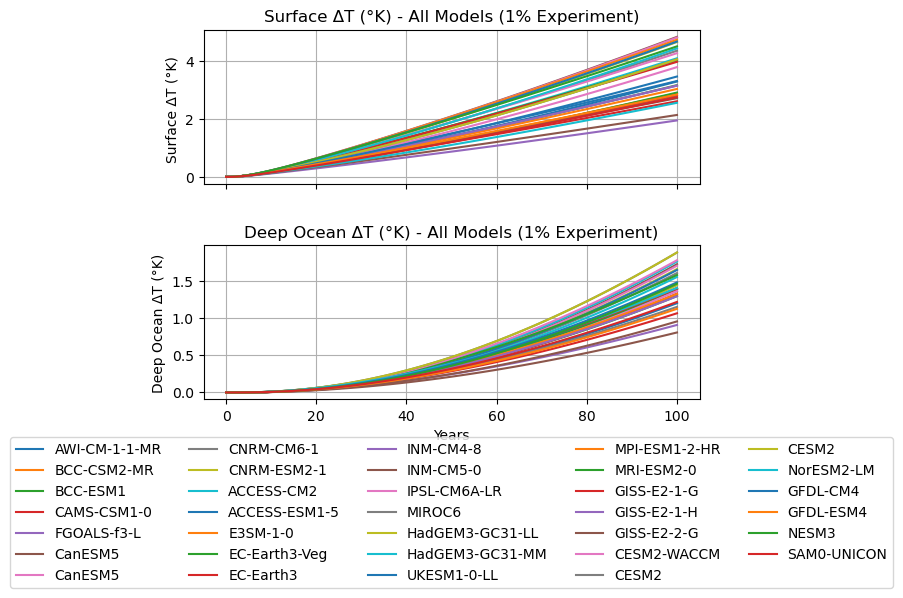

In [6]:
# -----------------------------------------------------------------------------
# Plotting the 100-year simulation for all models using model names for labels
# -----------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
available_models = range(len(model_names))  # Use the length of model_names

# Plot 1: Surface Temperature - All Models (using F2)
for model_idx in available_models:
    if model_idx in [17, 24, 25, 32, 38]:
        continue  # Skip missing models
    force = F2[model_idx]
    current_gamma = gamma[model_idx]
    current_lamb = lamb[model_idx]
    
    forcing = log_linear(ratio, force=force)
    Tout = run(t, forcing, gamma=current_gamma, lamb=current_lamb, cs=cs[0], cd=cd[0])
    Temp_sur = Tout[:, 0]
    
    # Label with the model name from the CSV
    ax1.plot(t, Temp_sur, label=model_names[model_idx])
ax1.set_ylabel('Surface ΔT (°K) ')
ax1.set_title('Surface ΔT (°K) - All Models (1% Experiment)')
ax1.grid(True)

# Plot 2: Deep Ocean Temperature - All Models (using F4)
for model_idx in available_models:
    if model_idx in [17, 24, 25, 32, 38]:
        continue  # Skip missing models
    force = F2[model_idx]
    current_gamma = gamma[model_idx]
    current_lamb = lamb[model_idx]
    
    forcing = log_linear(ratio, force=force)
    Tout = run(t, forcing, gamma=current_gamma, lamb=current_lamb, cs=cs[0], cd=cd[0])
    Temp_deep = Tout[:, 1]
    
    # Label with the model name from the CSV
    ax2.plot(t, Temp_deep, label=model_names[model_idx])
ax2.set_xlabel('Years')
ax2.set_ylabel('Deep Ocean ΔT (°K)')
ax2.set_title('Deep Ocean ΔT (°K) - All Models (1% Experiment)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)
ax2.grid(True)

plt.subplots_adjust(hspace=0.4)
plt.savefig('1_percent_CO2_experiment_CMIP6.png', bbox_inches='tight')
plt.show()